# 03. Análisis exploratorio de datos - Fashion Transparency Index 2023

### Objetivo del notebook

Realizar el análisis exploratorio de la base de datos integrada y depurada del Fashion Transparency Index 2023. Esta etapa busca caracterizar el comportamiento general de los indicadores de transparencia corporativa mediante estadísticas descriptivas y visualizaciones, con el fin de identificar patrones de divulgación, comparar las categorías Environment, Social y Governance (ESG), y evaluar las características de las variables binarias que serán utilizadas en el análisis de agrupamiento.

### Descripción general

El análisis exploratorio constituye una etapa previa al proceso de clustering y tiene como finalidad comprender la estructura y el contenido de la base de datos antes de aplicar técnicas de aprendizaje no supervisado. Para ello, se revisó la composición de la información, se describieron los niveles de divulgación de los indicadores de transparencia y se identificaron aquellos con mayor y menor frecuencia de reporte por parte de las empresas.
Asimismo, se compararon las categorías Environment, Social y Governance (ESG) y se evaluó la variabilidad de los indicadores binarios seleccionados para el análisis de agrupamiento. Los resultados obtenidos permitirán verificar que la información presenta las condiciones necesarias para continuar con la etapa de clustering.

In [87]:
# Importamos las librerías necesarias

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter


# Configuración general de pandas

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


# Definimos una paleta profesional para todo el análisis

AZUL_MARINO = "#17324D"
AZUL_SECUNDARIO = "#506B84"
GRIS_OSCURO = "#4A4A4A"
GRIS_MEDIO = "#A7ADB4"
GRIS_CLARO = "#E6E9ED"
NEGRO = "#1A1A1A"


# Establecemos una configuración visual general

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRIS_MEDIO,
    "axes.labelcolor": NEGRO,
    "axes.titlecolor": NEGRO,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.color": GRIS_OSCURO,
    "ytick.color": GRIS_OSCURO,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10
})

In [88]:
# Función para guardar las figuras del análisis

def guardar_figura(fig, nombre_archivo):
    """
    Guarda una figura en alta resolución dentro de la carpeta docs.
    """

    fig.savefig(
        f"../docs/{nombre_archivo}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

In [89]:
# Cargamos la base de datos limpia obtenida en el notebook anterior
base = pd.read_csv("/Users/avrilsalazar/Documents/FashionTransparency2023/processed/base_integrada_limpia.csv")

# Mostramos las primeras observaciones para verificar que la carga fue correcta
base.head()

,Answer Page,Metric,Company,Year,Value,Source Page,Answer ID,Original Source,Source Count,Comments,ISIN,Categoria
0,https://wikirate.org/Fashion_Revolution+Fashio...,Fashion Revolution+Fashion Transparency Index ...,Puma,2023,6.6399545215046025,NaN,NaN,NaN,NaN,NaN,DE0006969603;US7458781082;US7458782072,Environment
1,https://wikirate.org/Fashion_Revolution+5_Spot...,Fashion Revolution+5. Spotlight Issues Score (...,Puma,2023,5.777737773332444,NaN,NaN,NaN,NaN,NaN,DE0006969603;US7458781082;US7458782072,Environment
2,https://wikirate.org/~15202791,Fashion Revolution+Zero Deforestation Progress,Puma,2023,1,https://wikirate.org/~15072139,"15,202,791.000",https://annual-report.puma.com/2021/downloads/...,1.000,"Page(s) 16, Page(s) 116117",DE0006969603;US7458781082;US7458782072,Environment
3,https://wikirate.org/Fashion_Revolution+Fashio...,Fashion Revolution+Fashion Transparency Index ...,H&M,2023,7.109952921622202,NaN,NaN,NaN,NaN,NaN,SE0000106270;SE0000106288;SE0000157521;SE00001...,Environment
4,https://wikirate.org/Fashion_Revolution+5_Spot...,Fashion Revolution+5. Spotlight Issues Score (...,H&M,2023,6.4443777733324445,NaN,NaN,NaN,NaN,NaN,SE0000106270;SE0000106288;SE0000157521;SE00001...,Environment


### Revisión de la estructura de la base de datos

Antes de iniciar el análisis exploratorio, se revisa la estructura general de la base de datos. Esta verificación permite conocer el número de observaciones y variables disponibles, identificar el tipo de dato de cada columna y confirmar que la información fue importada correctamente.

In [90]:
# Consultamos las dimensiones de la base de datos
# El resultado indica el número de filas (observaciones)
# y columnas (variables) contenidas en la base
print(f"Dimensiones de la base: {base.shape[0]} filas y {base.shape[1]} columnas")

# Mostramos la información general de la base
# Se presenta el nombre de cada variable, el número de valores no nulos
# y el tipo de dato almacenado en cada columna
base.info()

Dimensiones de la base: 32000 filas y 12 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Answer Page      32000 non-null  object 
 1   Metric           32000 non-null  object 
 2   Company          32000 non-null  object 
 3   Year             32000 non-null  int64  
 4   Value            30744 non-null  object 
 5   Source Page      30500 non-null  object 
 6   Answer ID        10000 non-null  float64
 7   Original Source  10000 non-null  object 
 8   Source Count     10000 non-null  float64
 9   Comments         1972 non-null   object 
 10  ISIN             2596 non-null   object 
 11  Categoria        32000 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 2.9+ MB


### Revisión de valores faltantes

Como parte de la caracterización inicial de la base de datos, se verifica la presencia de valores faltantes en cada una de las variables. Esta revisión permite confirmar la integridad de la información y asegurar que las estadísticas descriptivas se calculen sobre datos completos.

In [91]:
# Calculamos el número de valores faltantes por variable
valores_faltantes = base.isna().sum()

# Mostramos únicamente las variables que presentan valores faltantes
valores_faltantes = valores_faltantes[valores_faltantes > 0]

# Presentamos el resumen de valores faltantes
display(valores_faltantes.to_frame(name="Valores faltantes"))

,Valores faltantes
Value,1256
Source Page,1500
Answer ID,22000
Original Source,22000
Source Count,22000
Comments,30028
ISIN,29404


Los valores faltantes se concentran en variables asociadas a información complementaria proporcionada por WikiRate, como identificadores de respuesta, fuentes originales, comentarios e identificadores ISIN. Estos campos no forman parte de la información utilizada en el análisis de transparencia y, por tanto, su ausencia no afecta la construcción de la base de datos ni las etapas posteriores del análisis.

### Composición general de la base de datos

Como primer paso del análisis exploratorio, se resume la composición general de la base de datos mediante el número de empresas, indicadores y observaciones incluidas. Esta revisión permite confirmar la cobertura de la información que será utilizada en las etapas posteriores del análisis.

In [92]:
# Calculamos un resumen general de la base de datos

resumen_base = pd.DataFrame({
    "Característica": [
        "Observaciones",
        "Empresas",
        "Indicadores",
        "Años"
    ],
    "Valor": [
        len(base),
        base["Company"].nunique(),
        base["Metric"].nunique(),
        base["Year"].nunique()
    ]
})

# Mostramos el resumen
display(resumen_base)

,Característica,Valor
0,Observaciones,32000
1,Empresas,250
2,Indicadores,128
3,Años,1


### Distribución de observaciones por categoría temática

Como parte del análisis exploratorio, se analiza la distribución de las observaciones entre las categorías temáticas presentes en la base de datos. Además de las dimensiones **Environment**, **Social** y **Governance**, el *Fashion Transparency Index 2023* incluye indicadores correspondientes a la categoría **Traceability**, la cual se incorpora al análisis descriptivo para documentar la composición completa de la información disponible.

Este resumen permite conocer la participación de cada categoría temática dentro de la base de datos antes de profundizar en el análisis de los indicadores de transparencia.

In [93]:
# Calculamos el número de observaciones por categoría temática

orden = [
    "Environment",
    "Social",
    "Governance",
    "Traceability"
]

resumen_categorias = (
    base["Categoria"]
    .value_counts()
    .reindex(orden, fill_value=0)
    .rename_axis("Categoria")
    .reset_index(name="Observaciones")
)

# Calculamos el porcentaje que representa cada categoría
resumen_categorias["Porcentaje"] = (
    resumen_categorias["Observaciones"]
    / len(base)
    * 100
).round(2)

# Mostramos el resumen
display(resumen_categorias)

,Categoria,Observaciones,Porcentaje
0,Environment,11500,35.940
1,Social,13000,40.620
2,Governance,6500,20.310
3,Traceability,1000,3.120


Para facilitar la comparación entre categorías, se presenta una representación gráfica de la distribución de las observaciones incluidas en la base de datos.

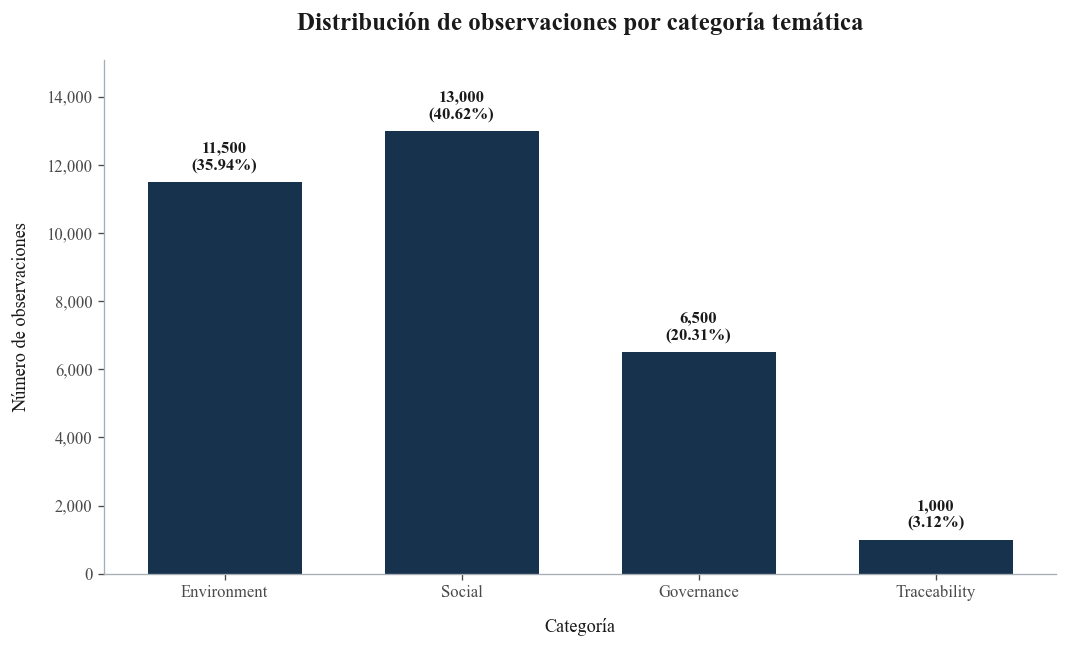

In [94]:
# Visualizamos la distribución de observaciones por categoría temática

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de barras
barras = ax.bar(
    resumen_categorias["Categoria"],
    resumen_categorias["Observaciones"],
    color=AZUL_MARINO,
    width=0.65
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Distribución de observaciones por categoría temática",
    pad=18
)

ax.set_xlabel("Categoría", labelpad=10)
ax.set_ylabel("Número de observaciones", labelpad=10)

# Aplicamos separadores de miles al eje vertical
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el número de observaciones y el porcentaje
# correspondiente sobre cada barra
for barra, observaciones, porcentaje in zip(
    barras,
    resumen_categorias["Observaciones"],
    resumen_categorias["Porcentaje"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 250,
        f"{observaciones:,.0f}\n({porcentaje:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio superior para las etiquetas
ax.set_ylim(
    0,
    resumen_categorias["Observaciones"].max() * 1.16
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(fig, "distribucion_observaciones_categoria")

plt.show()


La distribución de las observaciones evidencia que la base de datos no se encuentra equilibrada entre categorías temáticas. En conjunto, **Environment** y **Social** concentran el **76.56%** de las observaciones, mientras que **Governance** y **Traceability** representan el **23.44%** restante. Esta composición indica que la información disponible en el *Fashion Transparency Index 2023* se encuentra orientada principalmente hacia indicadores ambientales y sociales, aspecto que debe considerarse al interpretar los resultados obtenidos en las etapas posteriores del análisis exploratorio.

### Distribución de indicadores por categoría temática

Además de analizar la distribución de las observaciones, resulta importante conocer cómo se distribuyen los indicadores entre las distintas categorías temáticas. Este análisis permite identificar el peso de cada dimensión dentro de la estructura del índice, independientemente del número de observaciones registradas por empresa.

In [95]:
# Calculamos el número de indicadores por categoría temática

indicadores_categoria = (
    base[["Metric", "Categoria"]]
    .drop_duplicates()
    .groupby("Categoria")
    .size()
    .reindex(orden, fill_value=0)
    .reset_index(name="Indicadores")
)

# Calculamos el porcentaje de indicadores por categoría
indicadores_categoria["Porcentaje"] = (
    indicadores_categoria["Indicadores"]
    / indicadores_categoria["Indicadores"].sum()
    * 100
).round(2)

# Mostramos el resumen
display(indicadores_categoria)

,Categoria,Indicadores,Porcentaje
0,Environment,46,35.940
1,Social,52,40.620
2,Governance,26,20.310
3,Traceability,4,3.120


Se presenta una representación gráfica de la distribución de los indicadores que conforman el *Fashion Transparency Index 2023*.

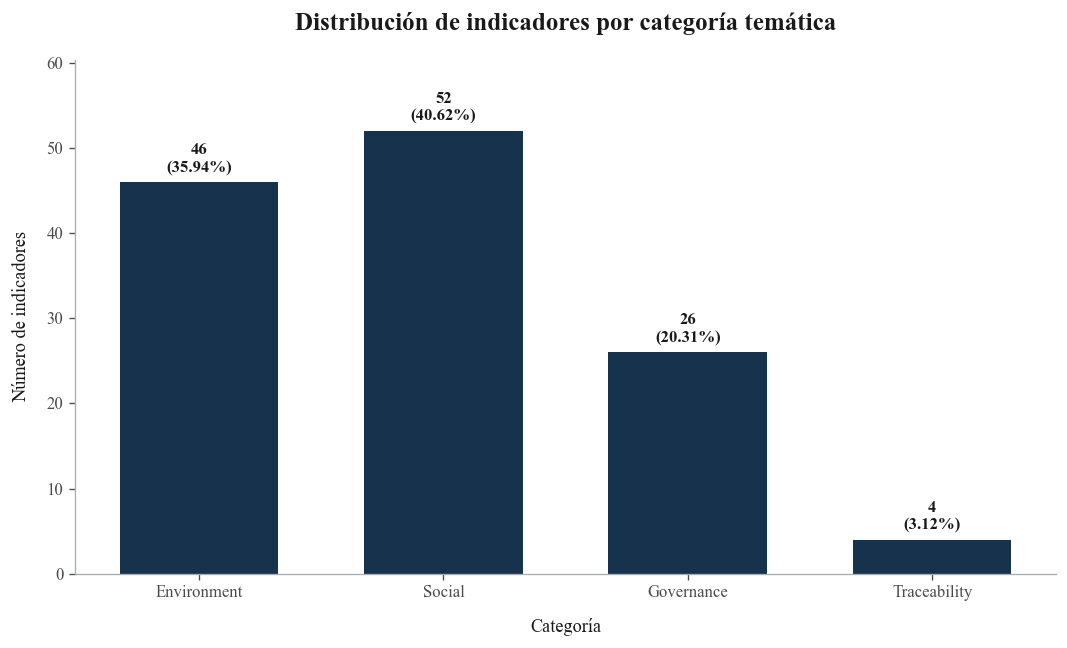

In [96]:
# Visualizamos la distribución de indicadores por categoría temática

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de barras
barras = ax.bar(
    indicadores_categoria["Categoria"],
    indicadores_categoria["Indicadores"],
    color=AZUL_MARINO,
    width=0.65
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Distribución de indicadores por categoría temática",
    pad=18
)

ax.set_xlabel("Categoría", labelpad=10)
ax.set_ylabel("Número de indicadores", labelpad=10)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el número de indicadores y el porcentaje correspondiente
for barra, indicadores, porcentaje in zip(
    barras,
    indicadores_categoria["Indicadores"],
    indicadores_categoria["Porcentaje"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.8,
        f"{indicadores}\n({porcentaje:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Dejamos espacio superior para las etiquetas
ax.set_ylim(
    0,
    indicadores_categoria["Indicadores"].max() * 1.16
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(fig, "distribucion_indicadores_categoria")

plt.show()

La distribución de los indicadores confirma el mismo patrón observado previamente para las observaciones. Esto se debe a que cada indicador fue evaluado para el mismo conjunto de **250 empresas**, por lo que la distribución de las observaciones es directamente proporcional al número de indicadores por categoría. No obstante, este análisis permite identificar la estructura del *Fashion Transparency Index 2023*, evidenciando que **Environment** y **Social** concentran **98 de los 128 indicadores** del índice, mientras que **Governance** y **Traceability** reúnen únicamente **30 indicadores**, lo que refleja una menor representación de estas dimensiones dentro del diseño general del instrumento de evaluación.

### Nivel de divulgación de los indicadores

Una vez descrita la composición de la base de datos, se analiza el nivel de divulgación de los indicadores de transparencia.

In [97]:
# Cargamos la matriz binaria utilizada para el análisis

matriz = pd.read_csv("/Users/avrilsalazar/Documents/FashionTransparency2023/processed/matriz_empresas_clustering.csv")

# Calculamos el porcentaje de divulgación por indicador

divulgacion = (
    matriz
    .drop(columns="Company")
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

divulgacion.columns = ["Indicador", "Porcentaje de divulgación"]

In [98]:
# Calculamos estadísticas descriptivas de las tasas de divulgación

estadisticas_divulgacion = (
    divulgacion["Porcentaje de divulgación"]
    .describe()
    .to_frame(name="Valor")
)

# Mostramos el resumen estadístico
display(estadisticas_divulgacion)

,Valor
count,108.000
mean,25.593
std,19.940
min,0.800
25%,7.200
50%,22.600
75%,37.700
max,75.200


A continuación un histograma que muestra la frecuencia de los porcentajes de divulgación observados.

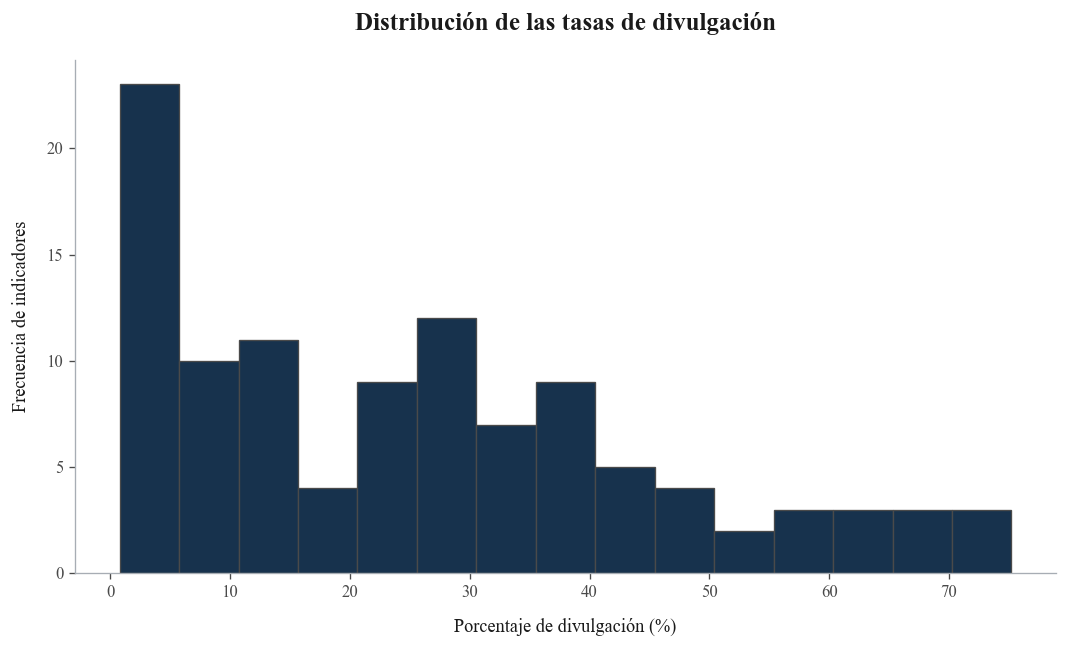

In [99]:
# Visualizamos la distribución de las tasas de divulgación

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos el histograma
ax.hist(
    divulgacion["Porcentaje de divulgación"],
    bins=15,
    color=AZUL_MARINO,
    edgecolor=GRIS_OSCURO,
    linewidth=0.8
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Distribución de las tasas de divulgación",
    pad=18
)

ax.set_xlabel("Porcentaje de divulgación (%)", labelpad=10)
ax.set_ylabel("Frecuencia de indicadores", labelpad=10)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(fig, "distribucion_tasas_divulgacion")

plt.show()

Las tasas de divulgación presentan una elevada variabilidad entre indicadores, con valores que oscilan entre **0.8%** y **75.2%**, lo que representa un rango de **74.4 puntos porcentuales**. En promedio, los indicadores son divulgados por el **25.59%** de las empresas. Además, la mediana de **22.60%** indica que la mitad de los indicadores presenta un nivel de divulgación igual o inferior a ese porcentaje. Asimismo, el histograma muestra una mayor concentración de indicadores en los niveles bajos de divulgación y una disminución progresiva de la frecuencia conforme aumenta el porcentaje de empresas que reportan información. 

En conjunto, estos resultados evidencian que la transparencia corporativa no se distribuye de manera uniforme entre los indicadores, sino que existe un número reducido de prácticas ampliamente divulgadas y una proporción considerable de indicadores con bajos niveles de reporte.

### Indicadores con mayor nivel de divulgación

Una vez caracterizada la distribución general de las tasas de divulgación, se identifican los indicadores con mayor porcentaje de reporte por parte de las empresas. 

In [100]:
# Identificamos los diez indicadores con mayor nivel de divulgación

top_10_divulgacion = divulgacion.head(10)

# Mostramos el resultado
display(top_10_divulgacion)

,Indicador,Porcentaje de divulgación
0,Fashion Revolution+Supply Chain Policies Align...,75.200
1,Fashion Revolution+Plan for Improving Environm...,71.600
2,Fashion Revolution+Supply Chain Policies Are C...,71.200
3,Fashion Revolution+Describes Human Rights Due ...,67.600
4,Fashion Revolution+Grievance Mechanism - Direc...,67.200
5,Fashion Revolution+Implementation of Board Lev...,66.000
6,Fashion Revolution+New Production Facility Cri...,63.600
7,Fashion Revolution+Reports on Efforts to Impro...,61.200
8,Fashion Revolution+Grievance Mechanism - Suppl...,61.200
9,Fashion Revolution+Discloses Content of Scope ...,59.600


In [101]:
# Reconstruimos la tabla de divulgación con los nombres originales

divulgacion = (
    matriz
    .drop(columns="Company")
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

divulgacion.columns = [
    "Indicador_original",
    "Porcentaje de divulgación"
]

# Recuperamos la categoría temática correspondiente a cada indicador

categorias = (
    base[["Metric", "Categoria"]]
    .drop_duplicates()
    .rename(columns={"Metric": "Indicador_original"})
)

# Incorporamos la categoría temática utilizando los nombres originales

divulgacion = divulgacion.merge(
    categorias,
    on="Indicador_original",
    how="left",
    validate="one_to_one"
)

# Creamos una versión limpia del nombre para tablas y gráficas

divulgacion["Indicador"] = (
    divulgacion["Indicador_original"]
    .str.replace("Fashion Revolution+", "", regex=False)
)

# Reordenamos las columnas

divulgacion = divulgacion[
    [
        "Categoria",
        "Indicador",
        "Porcentaje de divulgación"
    ]
]

# Verificamos que no existan categorías faltantes

print(
    "Categorías faltantes:",
    divulgacion["Categoria"].isna().sum()
)

# Seleccionamos los diez indicadores con mayor divulgación

top_10_divulgacion = divulgacion.head(10).copy()

display(top_10_divulgacion)

Categorías faltantes: 0


,Categoria,Indicador,Porcentaje de divulgación
0,Governance,Supply Chain Policies Align with International...,75.200
1,Environment,Plan for Improving Environmental Impacts,71.600
2,Governance,Supply Chain Policies Are Contractual,71.200
3,Social,Describes Human Rights Due Diligence Process,67.600
4,Social,Grievance Mechanism - Direct Employees,67.200
5,Governance,Implementation of Board Level Accountability D...,66.000
6,Social,New Production Facility Criteria,63.600
7,Environment,Reports on Efforts to Improve Environmental Im...,61.200
8,Social,Grievance Mechanism - Supply Chain Workers,61.200
9,Environment,"Discloses Content of Scope 1, 2 and 3 Emissions",59.600


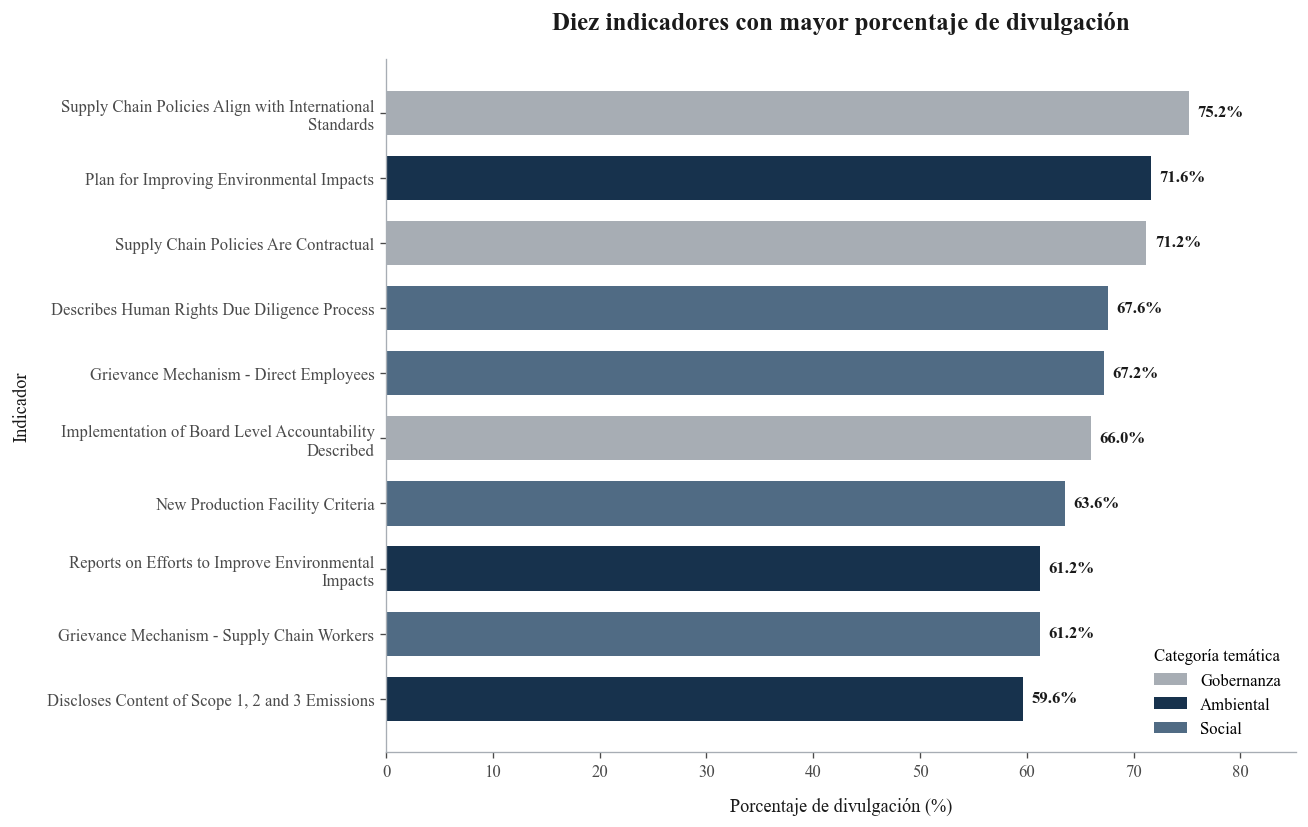

In [102]:
# Visualizamos los diez indicadores con mayor porcentaje de divulgación

import textwrap
from matplotlib.patches import Patch

# Definimos los colores de las categorías temáticas

COLOR_CATEGORIAS = {
    "Environment": AZUL_MARINO,
    "Social": AZUL_SECUNDARIO,
    "Governance": GRIS_MEDIO,
    "Traceability": GRIS_CLARO
}

# Traducimos las categorías únicamente para fines de presentación

CATEGORIAS_ES = {
    "Environment": "Ambiental",
    "Social": "Social",
    "Governance": "Gobernanza",
    "Traceability": "Trazabilidad"
}

# Creamos una copia para preparar las etiquetas de la figura

top_10_grafica = top_10_divulgacion.copy()

# Dividimos automáticamente los nombres largos en varias líneas

top_10_grafica["Indicador_visual"] = (
    top_10_grafica["Indicador"]
    .apply(lambda texto: textwrap.fill(texto, width=48))
)

# Asignamos un color según la categoría temática

colores = (
    top_10_grafica["Categoria"]
    .map(COLOR_CATEGORIAS)
)

# Construimos la figura

fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    top_10_grafica["Indicador_visual"],
    top_10_grafica["Porcentaje de divulgación"],
    color=colores,
    height=0.68
)

# Incorporamos el título y los nombres de los ejes

ax.set_title(
    "Diez indicadores con mayor porcentaje de divulgación",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de divulgación (%)",
    labelpad=10
)

ax.set_ylabel(
    "Indicador",
    labelpad=10
)

# Mostramos el indicador con mayor divulgación en la parte superior

ax.invert_yaxis()

# Eliminamos los bordes que no aportan información

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje al final de cada barra

for barra, valor in zip(
    barras,
    top_10_grafica["Porcentaje de divulgación"]
):
    ax.text(
        valor + 0.8,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}%",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Construimos la leyenda con los nombres de las categorías en español

categorias_presentes = (
    top_10_grafica["Categoria"]
    .drop_duplicates()
)

elementos_leyenda = [
    Patch(
        facecolor=COLOR_CATEGORIAS[categoria],
        label=CATEGORIAS_ES[categoria]
    )
    for categoria in categorias_presentes
]

ax.legend(
    handles=elementos_leyenda,
    title="Categoría temática",
    frameon=False,
    loc="lower right"
)

# Dejamos espacio para mostrar los porcentajes

ax.set_xlim(
    0,
    top_10_grafica["Porcentaje de divulgación"].max() + 10
)

# Ajustamos los márgenes

fig.tight_layout()

# Guardamos la figura en alta resolución

guardar_figura(
    fig,
    "top_10_indicadores_divulgacion"
)

plt.show()

Los indicadores con mayor porcentaje de divulgación presentan niveles de reporte que oscilan entre **59.6%** y **75.2%** de las empresas evaluadas. El indicador con mayor divulgación corresponde a **Supply Chain Policies Align with International Standards** (*informa si las políticas para la cadena de suministro están alineadas con estándares internacionales*), reportado por el **75.2%** de las empresas, mientras que el décimo lugar (**Discloses Content of Scope 1, 2 and 3 Emissions** (*divulga el contenido de las emisiones de alcance 1, 2 y 3*)) alcanza un **59.6%**. La diferencia entre ambos es de **15.6 puntos porcentuales**, lo que indica que incluso entre las prácticas más ampliamente divulgadas existe variabilidad en el grado de adopción.

Asimismo, se observa que los diez indicadores pertenecen exclusivamente a las categorías **Gobernanza**, **Ambiental** y **Social**. En particular, **cuatro** corresponden a la dimensión Social, **tres** a Gobernanza y **tres** a Ambiental, mientras que **ningún** indicador de Trazabilidad aparece entre los niveles más altos de divulgación. En conjunto, estos resultados sugieren que las empresas priorizan la publicación de políticas corporativas, mecanismos de gobernanza, procesos de debida diligencia y acciones relacionadas con la gestión de impactos ambientales y sociales, por encima de otros ámbitos de transparencia.

### Indicadores con menor nivel de divulgación

A continuación, se identifican los diez indicadores con menor porcentaje de divulgación dentro del Fashion Transparency Index 2023. Este análisis permite reconocer las prácticas sobre las cuales las empresas proporcionan información con menor frecuencia.

In [103]:
# Identificamos los diez indicadores con menor nivel de divulgación

bottom_10_divulgacion = divulgacion.tail(10).copy()

# Mostramos el resultado

display(bottom_10_divulgacion)

,Categoria,Indicador,Porcentaje de divulgación
98,Social,Discloses Quantity of Orders with Labor Cost P...,2.400
99,Governance,Discloses Free on Board (FOB) Price Changes (C...,2.000
100,Social,Discloses Strategy to Achieving Living Wage,2.000
101,Environment,Discloses Percentage of Workers Paid By Piece ...,1.600
102,Social,Discloses Progress toward the payment of a Liv...,1.600
103,Social,Publishes Percentage or Number of Workers Earn...,1.200
104,Social,Discloses Number of Collective Bargaining Agre...,1.200
105,Governance,Discloses Policy on Up-Front Supplier Payments,0.800
106,Environment,Commitment to Degrowth,0.800
107,Governance,Publishes Standard Supplier Agreement Template,0.800


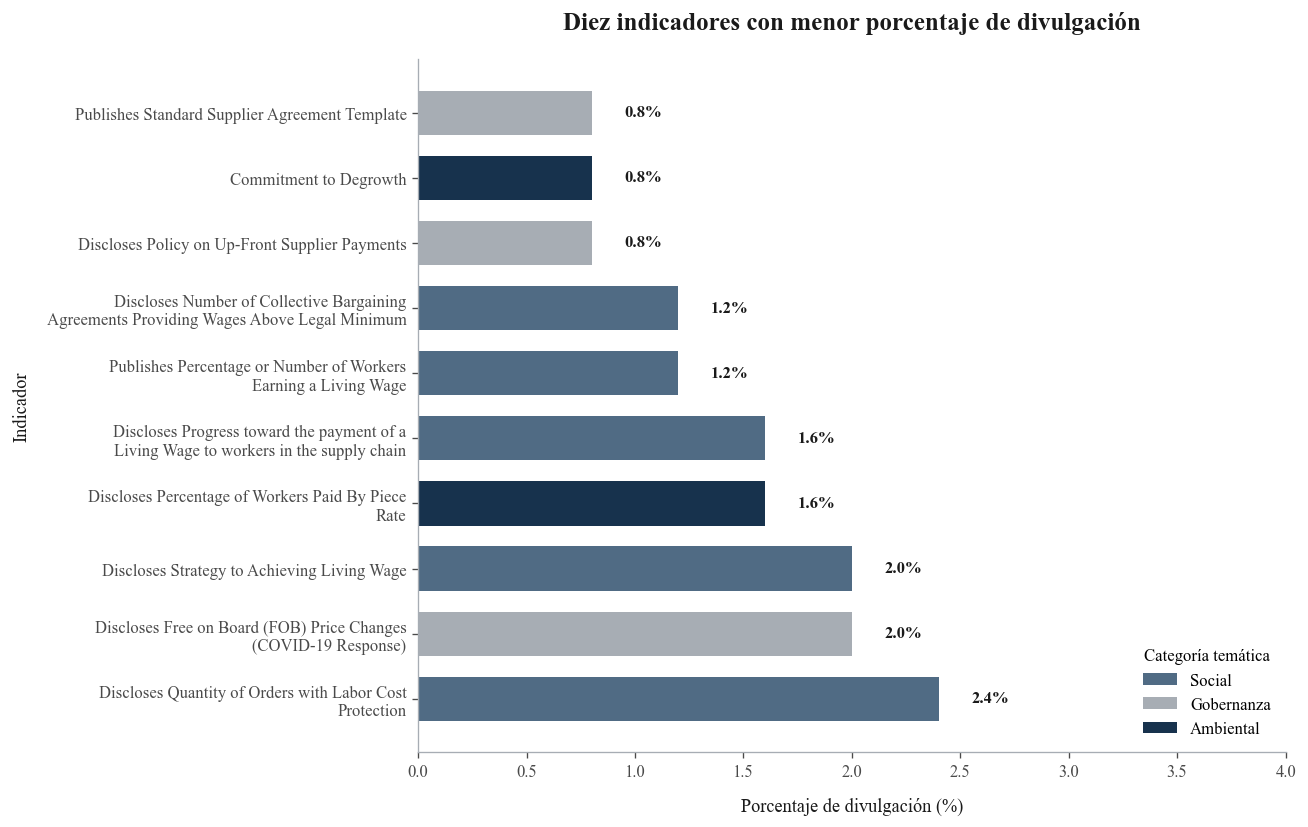

In [104]:
# Visualizamos los diez indicadores con menor porcentaje de divulgación

import textwrap
from matplotlib.patches import Patch

# Creamos una copia para preparar las etiquetas de la figura

bottom_10_grafica = bottom_10_divulgacion.copy()

# Dividimos automáticamente los nombres largos en varias líneas

bottom_10_grafica["Indicador_visual"] = (
    bottom_10_grafica["Indicador"]
    .apply(lambda texto: textwrap.fill(texto, width=48))
)

# Asignamos un color según la categoría temática

colores = (
    bottom_10_grafica["Categoria"]
    .map(COLOR_CATEGORIAS)
)

# Construimos la figura

fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    bottom_10_grafica["Indicador_visual"],
    bottom_10_grafica["Porcentaje de divulgación"],
    color=colores,
    height=0.68
)

# Incorporamos el título y los nombres de los ejes

ax.set_title(
    "Diez indicadores con menor porcentaje de divulgación",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de divulgación (%)",
    labelpad=10
)

ax.set_ylabel(
    "Indicador",
    labelpad=10
)

# Eliminamos los bordes que no aportan información

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje al final de cada barra

for barra, valor in zip(
    barras,
    bottom_10_grafica["Porcentaje de divulgación"]
):
    ax.text(
        valor + 0.15,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}%",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Construimos la leyenda

categorias_presentes = (
    bottom_10_grafica["Categoria"]
    .drop_duplicates()
)

elementos_leyenda = [
    Patch(
        facecolor=COLOR_CATEGORIAS[categoria],
        label=CATEGORIAS_ES[categoria]
    )
    for categoria in categorias_presentes
]

ax.legend(
    handles=elementos_leyenda,
    title="Categoría temática",
    frameon=False,
    loc="lower right"
)

# Dejamos espacio para mostrar los porcentajes

ax.set_xlim(0, 4)

# Ajustamos los márgenes

fig.tight_layout()

# Guardamos la figura

guardar_figura(
    fig,
    "bottom_10_indicadores_divulgacion"
)

plt.show()


Los indicadores con menor porcentaje de divulgación presentan niveles de reporte que oscilan entre **0.8%** y **2.4%** de las empresas evaluadas. El indicador con mayor divulgación dentro de este grupo corresponde a **Discloses Quantity of Orders with Labor Cost Protection** (*divulga la cantidad de pedidos que incluyen protección de los costos laborales*), reportado únicamente por el **2.4%** de las empresas. En contraste, los indicadores **Discloses Policy on Up-Front Supplier Payments** (*divulga una política de pagos anticipados a proveedores*), **Commitment to Degrowth** (*compromiso con estrategias de decrecimiento para reducir el impacto ambiental*) y **Publishes Standard Supplier Agreement Template** (*publica un modelo estándar de contrato para proveedores*) son reportados por apenas el **0.8%** de las empresas. La diferencia entre el indicador con mayor y menor divulgación dentro de este grupo es de **1.6 puntos porcentuales**, lo que evidencia que todos estos indicadores presentan niveles de divulgación extremadamente bajos.

Asimismo, se observa que **cinco** de los diez indicadores pertenecen a la categoría **Social**, **tres** a **Gobernanza** y **dos** a **Ambiental**, mientras que nuevamente no aparece ningún indicador de **Trazabilidad**. Destaca que la mayoría de estos indicadores está relacionada con **salarios dignos, negociación colectiva, condiciones de pago a proveedores y prácticas laborales**, temas que requieren un mayor nivel de transparencia sobre la relación de las empresas con sus trabajadores y su cadena de suministro. En conjunto, estos resultados sugieren que, aunque algunas empresas divulgan ampliamente sus políticas generales de sostenibilidad y gobernanza, existe una marcada resistencia a reportar información específica sobre condiciones laborales, remuneración y mecanismos contractuales, lo que constituye una de las principales brechas de transparencia observadas en el Fashion Transparency Index 2023.